Nice — below is a **systematic Week-0 plan** built around the code you already posted. I’ll show each step **in order**, explain why it’s there, and include copy-pasteable code cells you can run in Colab / local. I also include EDA plots you asked for (length distributions, ratios, top words, vocab growth, Zipf plot, rare-word stats, and seq_len/truncation analysis).

> **Note:** I can’t run the code here; please run these cells in your Colab/VSCode. I designed everything to work with your dataset structure and to be incremental so you can run one cell at a time and inspect outputs.

---

# Week-0 — Step-by-step (code + explanation)

## 0. environment + imports

Run this first cell. It installs/loads libraries and sets seeds.

```python
# Cell 0 - setup
import os, json, re, string, unicodedata, pickle
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random

# NLP / tokenization
import nltk
nltk.download('punkt', quiet=True)
from nltk.tokenize import word_tokenize

# Optional: sentencepiece for subword tokenization
# !pip install sentencepiece   # uncomment and run in Colab if not installed
import sentencepiece as spm

# PyTorch basics (for later DataLoader)
import torch
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

# plotting style
sns.set(style="whitegrid", palette="muted", font_scale=1.0)

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
```

---

## 1. Load your JSON files (wrap your original code into a function)

This is a robust loader that handles missing target in validation and collects IDs.

```python
# Cell 1 - load data (adapted from your code)
def load_parallel_json(paths, language_pair="English-Hindi"):
    src_train, tgt_train = [], []
    src_val, tgt_val = [], []
    id_train, id_val = [], []
    for p in paths:
        with open(p, 'r', encoding='utf-8') as f:
            data = json.load(f)
        for lp, language_data in data.items():
            if lp != language_pair: 
                continue
            for data_type, entries in language_data.items():
                for eid, entry in entries.items():
                    src = entry.get("source", "").strip()
                    tgt = entry.get("target")  # may be None in some val files
                    if data_type.lower().startswith("val") or data_type.lower().startswith("validation"):
                        src_val.append(src)
                        if tgt is not None:
                            tgt_val.append(tgt)
                        id_val.append(eid)
                    else:
                        src_train.append(src)
                        tgt_train.append(tgt)
                        id_train.append(eid)
    return src_train, tgt_train, src_val, tgt_val, id_train, id_val

# Replace these with your actual paths (your original path strings)
train_json = '/content/drive/MyDrive/NLP/MT/train_data1.json'
val_json   = '/content/drive/MyDrive/NLP/MT/val_data1.json'

src_train, tgt_train, src_val, tgt_val, id_train, id_val = load_parallel_json([train_json], "English-Hindi")

print("Train pairs:", len(src_train))
print("Val sources:", len(src_val), "Val targets (available):", len(tgt_val))
```

---

## 2. Cleaning utilities

Better Unicode normalization, optional removal of Latin tokens from Hindi, and controlled punctuation removal.

```python
# Cell 2 - cleaning functions
def normalize_text(s):
    if s is None: 
        return ""
    s = unicodedata.normalize("NFKC", s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def remove_punct_and_digits_keep_indic(s):
    # removes ASCII punctuation and digits; keeps Indic punctuation if needed
    # simple approach (you can extend with IndicNLP)
    return ''.join(ch for ch in s if ch not in string.punctuation and not ch.isdigit())

def remove_isolated_latin_tokens(s):
    # Remove words that are purely ASCII latin alphabets (e.g., "hello")
    return ' '.join([w for w in s.split() if not re.fullmatch(r'[A-Za-z]+', w)])

def preprocess_text(s, lower=True, remove_punct=True, remove_latin=False):
    s = normalize_text(s)
    if lower:
        s = s.lower()
    if remove_punct:
        s = remove_punct_and_digits_keep_indic(s)
    if remove_latin:
        s = remove_isolated_latin_tokens(s)
    s = s.strip()
    return s
```

**Notes:**

* I do not remove digits/punctuation blindly from target Hindi—use `remove_latin=True` when you want to remove stray English tokens in Hindi.
* You may later use IndicNLP normalizers for complex normalization.

---

## 3. Tokenize (word-level) — using NLTK (simple & transparent)

Tokenize train & val. You already did this; this is a cleaned, clearer version.

```python
# Cell 3 - tokenization (word-level)
def tokenize_list(sentences, lower=True, remove_punct=True, remove_latin=False):
    tokens = []
    for s in sentences:
        s_clean = preprocess_text(s, lower=lower, remove_punct=remove_punct, remove_latin=remove_latin)
        if s_clean == "":
            tokens.append([])   # keep empty to inspect later
        else:
            toks = word_tokenize(s_clean)
            tokens.append(toks)
    return tokens

# Apply:
en_train_tokens = tokenize_list(src_train, lower=True, remove_punct=True, remove_latin=False)
en_val_tokens   = tokenize_list(src_val, lower=True, remove_punct=True, remove_latin=False)

# For Hindi target, optionally remove Latin:
hi_train_tokens = tokenize_list(tgt_train, lower=False, remove_punct=True, remove_latin=True)  # case kept for Indic
hi_val_tokens   = tokenize_list(tgt_val, lower=False, remove_punct=True, remove_latin=True)

# Quick checks
print("Example source raw:", src_train[0][:200])
print("Example source tokenized:", en_train_tokens[0][:20])
print("Example target raw:", tgt_train[0][:200] if tgt_train else "no target")
print("Example target tokenized:", hi_train_tokens[0][:20] if hi_train_tokens else "no tokens")
```

---

## 4. Basic dataset QC & cleaning decisions

Remove empty / extremely short pairs, and make a filtered dataset to work with.

```python
# Cell 4 - filter out bad pairs
filtered_src, filtered_tgt, filtered_ids = [], [], []
for s_tok, t_tok, sid in zip(en_train_tokens, hi_train_tokens, id_train):
    # Drop if either side is empty or length < 1 token
    if not s_tok or not t_tok or len(s_tok) < 1 or len(t_tok) < 1:
        continue
    filtered_src.append(s_tok)
    filtered_tgt.append(t_tok)
    filtered_ids.append(sid)

print("Filtered train size:", len(filtered_src))
# Replace train lists with filtered
en_train_tokens = filtered_src
hi_train_tokens = filtered_tgt
id_train = filtered_ids
```

---

## 5. Vocabulary: build word-level vocab (add <PAD>, <SOS>, <EOS>, <UNK>)

We add `<UNK>` — important.

```python
# Cell 5 - build vocab (word-level)
PAD, SOS, EOS, UNK = "<PAD>", "<SOS>", "<EOS>", "<UNK>"

def build_vocab(token_lists, max_vocab=None, min_freq=1, add_special=[PAD,SOS,EOS,UNK]):
    counter = Counter(w for sent in token_lists for w in sent)
    # filter by min_freq
    items = [w for w,f in counter.items() if f >= min_freq]
    # sort by frequency
    items.sort(key=lambda w: -counter[w])
    if max_vocab:
        items = items[:max_vocab - len(add_special)]
    index2word = add_special + items
    word2index = {w:i for i,w in enumerate(index2word)}
    return index2word, word2index, counter

# Build separate vocabs for source & target
en_index2word, en_word2index, en_counter = build_vocab(en_train_tokens, max_vocab=30000, min_freq=1)
hi_index2word, hi_word2index, hi_counter = build_vocab(hi_train_tokens, max_vocab=30000, min_freq=1)

print("En vocab size:", len(en_index2word))
print("Hi vocab size:", len(hi_index2word))
```

---

## 6. Encode sentences (no padding yet — we’ll let collate_fn pad dynamically)

We encode to lists of token ids with SOS/EOS. Do not pad now to keep dynamic batching simple.

```python
# Cell 6 - encode (returns torch.LongTensor of length N)
def encode_tokens(tokens, word2index, add_sos=True, add_eos=True):
    idxs = []
    if add_sos:
        idxs.append(word2index[SOS])
    for w in tokens:
        idxs.append(word2index.get(w, word2index[UNK]))
    if add_eos:
        idxs.append(word2index[EOS])
    return torch.tensor(idxs, dtype=torch.long)

# Create list of (src_tensor, tgt_tensor)
encoded_pairs = [(encode_tokens(s, en_word2index), encode_tokens(t, hi_word2index))
                 for s,t in zip(en_train_tokens, hi_train_tokens)]
print("example encoded len", [x.size(0) for x,_ in encoded_pairs[:5]])
```

---

## 7. `collate_fn` + DataLoader with dynamic padding

This is cleaner than creating fixed numpy arrays up front.

```python
# Cell 7 - collate_fn and DataLoader
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_lens = torch.tensor([s.size(0) for s in src_batch], dtype=torch.long)
    tgt_lens = torch.tensor([t.size(0) for t in tgt_batch], dtype=torch.long)
    # pad_sequence -> (batch, max_len)
    src_padded = pad_sequence(src_batch, batch_first=True, padding_value=en_word2index[PAD])
    tgt_padded = pad_sequence(tgt_batch, batch_first=True, padding_value=hi_word2index[PAD])
    return src_padded, src_lens, tgt_padded, tgt_lens

batch_size = 64
train_loader = DataLoader(encoded_pairs, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
# quick iterate to test shapes
for src_p, src_lens, tgt_p, tgt_lens in train_loader:
    print("src_p", src_p.shape, "tgt_p", tgt_p.shape)
    break
```

---

## 8. EDA: token/length statistics + plots

Run each cell and inspect the saved figures. I save them to local notebook directory; you can change paths.

### 8.1 Sentence length histograms (tokens)

```python
# Cell 8.1 - length histograms
src_lens = [len(s) for s in en_train_tokens]
tgt_lens = [len(t) for t in hi_train_tokens]

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(src_lens, bins=50, kde=False)
plt.title('Source (English) token length distribution')
plt.xlabel("tokens")

plt.subplot(1,2,2)
sns.histplot(tgt_lens, bins=50, kde=False)
plt.title('Target (Hindi) token length distribution')
plt.xlabel("tokens")

plt.tight_layout()
plt.savefig("length_histograms.png", dpi=150)
plt.show()
```

### 8.2 Source vs Target length scatter and ratio

```python
# Cell 8.2 - length scatter & ratio
plt.figure(figsize=(6,6))
plt.scatter(src_lens, tgt_lens, alpha=0.25, s=6)
plt.xlabel("source len")
plt.ylabel("target len")
plt.title("Source vs Target length (tokens)")
plt.savefig("len_scatter.png", dpi=150)
plt.show()

# ratio distribution
ratios = np.array(tgt_lens) / (np.array(src_lens) + 1e-8)
plt.figure(figsize=(6,3))
sns.histplot(ratios, bins=50)
plt.title("Target / Source length ratio")
plt.savefig("len_ratio_hist.png", dpi=150)
plt.show()
```

### 8.3 Top-k frequent tokens (bar plot)

```python
# Cell 8.3 - top words
def plot_top_k(counter, k=30, title="Top tokens", save_name="top_tokens.png"):
    most = counter.most_common(k)
    words, freqs = zip(*most)
    plt.figure(figsize=(8,8))
    sns.barplot(x=list(freqs), y=list(words))
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_name, dpi=150)
    plt.show()

plot_top_k(en_counter, 30, "Top 30 English tokens", "en_top30.png")
plot_top_k(hi_counter, 30, "Top 30 Hindi tokens", "hi_top30.png")
```

### 8.4 Rare words (counts & proportion)

```python
# Cell 8.4 - rare word counts
def rare_word_stats(counter, thresholds=[1,2,5,10]):
    freqs = np.array(list(counter.values()))
    total_types = len(freqs)
    stats = {}
    for t in thresholds:
        stats[t] = int((freqs <= t).sum())
    return total_types, stats

en_types, en_rare = rare_word_stats(en_counter)
hi_types, hi_rare = rare_word_stats(hi_counter)
print("English types:", en_types, "rare:", en_rare)
print("Hindi types:", hi_types, "rare:", hi_rare)
```

### 8.5 Vocab growth curve (type-token)

```python
# Cell 8.5 - vocab growth
def vocab_growth_curve(token_lists):
    seen = set()
    growth = []
    for sent in token_lists:
        for w in sent:
            seen.add(w)
            growth.append(len(seen))
    return growth

growth = vocab_growth_curve(en_train_tokens)
plt.figure(figsize=(8,3))
plt.plot(growth)
plt.title("Vocabulary growth (English, cumulative unique tokens while scanning)")
plt.xlabel("tokens scanned")
plt.ylabel("unique types")
plt.savefig("vocab_growth_en.png", dpi=150)
plt.show()
```

### 8.6 Zipf plot (rank vs frequency log-log)

```python
# Cell 8.6 - Zipf plot
def zipf_plot(counter, save_name="zipf.png"):
    freqs_sorted = np.array(sorted(counter.values(), reverse=True))
    ranks = np.arange(1, len(freqs_sorted) + 1)
    plt.figure(figsize=(6,4))
    plt.loglog(ranks, freqs_sorted, marker='.')
    plt.title("Zipf-like rank-frequency plot")
    plt.xlabel("rank (log)")
    plt.ylabel("frequency (log)")
    plt.savefig(save_name, dpi=150)
    plt.show()

zipf_plot(en_counter, "zipf_en.png")
zipf_plot(hi_counter, "zipf_hi.png")
```

### 8.7 seq_length choice check (your `seq_length = 20`)

Compute proportion of sentences that would be truncated given `seq_length`.

```python
# Cell 8.7 - seq_len truncation check
SEQ_LEN = 20  # your current choice (counts tokens excluding SOS/EOS)
src_long_prop = sum(1 for l in src_lens if (l + 2) > SEQ_LEN) / len(src_lens)  # +2 for SOS/EOS
tgt_long_prop = sum(1 for l in tgt_lens if (l + 2) > SEQ_LEN) / len(tgt_lens)
print(f"Proportion of source sentences that will be truncated at seq_len={SEQ_LEN}: {src_long_prop:.3f}")
print(f"Proportion of target sentences that will be truncated at seq_len={SEQ_LEN}: {tgt_long_prop:.3f}")
```

If the proportion is > ~0.05 (5%), consider increasing `seq_length` or using subword tokenization (next section).

---

## 9. Optional: Train SentencePiece subword tokenizers (recommended if many OOVs)

If you saw many rare words / long tails, train SentencePiece on **only** your provided training texts (complying with competition rules).

```python
# Cell 9 - prepare raw text files for sentencepiece training
# Save raw (preprocessed) train corpora to disk, one sentence per line
with open("sp_en_train.txt", "w", encoding="utf-8") as f:
    for s in src_train:
        f.write(preprocess_text(s, lower=True, remove_punct=False) + "\n")

with open("sp_hi_train.txt", "w", encoding="utf-8") as f:
    for t in tgt_train:
        f.write(preprocess_text(t, lower=False, remove_punct=False, remove_latin=True) + "\n")

# Train two separate models (src + tgt)
VOCAB_SIZE = 8000  # tune: 4k-32k depending on data size
spm.SentencePieceTrainer.Train(f"--input=sp_en_train.txt --model_prefix=sp_en --vocab_size={VOCAB_SIZE} --model_type=bpe --character_coverage=1.0")
spm.SentencePieceTrainer.Train(f"--input=sp_hi_train.txt --model_prefix=sp_hi --vocab_size={VOCAB_SIZE} --model_type=bpe --character_coverage=1.0")

# Load models
sp_en = spm.SentencePieceProcessor()
sp_en.Load("sp_en.model")
sp_hi = spm.SentencePieceProcessor()
sp_hi.Load("sp_hi.model")

# Example encoding
print("SP example:", sp_en.encode_as_pieces("This is a test sentence."))
```

If you use subword models, encode via `sp_en.encode_as_ids()` and build vocab using the SP vocab (no extra UNK needed because SP has its own `<unk>` token).

---

## 10. Save processed artifacts

Save token lists, encoded pairs and vocabs so Week-1 trains can load them directly.

```python
# Cell 10 - save artifacts
os.makedirs("processed", exist_ok=True)
with open("processed/vocabs.pkl", "wb") as f:
    pickle.dump({
        "en_index2word": en_index2word,
        "en_word2index": en_word2index,
        "hi_index2word": hi_index2word,
        "hi_word2index": hi_word2index
    }, f)

# Save tokenized lists for quick reload
with open("processed/tokenized_train.pkl", "wb") as f:
    pickle.dump({
        "en_train_tokens": en_train_tokens,
        "hi_train_tokens": hi_train_tokens,
        "id_train": id_train
    }, f)

print("Saved processed artifacts in ./processed/")
```

---

## 11. Quick sanity checks & tiny overfit dataset (for debugging model code next week)

Create a tiny subset to use in Week-1 for sanity overfitting.

```python
# Cell 11 - tiny overfit dataset
SMALL_N = min(100, len(encoded_pairs))
small_pairs = encoded_pairs[:SMALL_N]
small_loader = DataLoader(small_pairs, batch_size=16, shuffle=True, collate_fn=collate_fn)
print("Small loader batches:", len(small_loader))
# Save small set
with open("processed/small_pairs.pkl", "wb") as f:
    pickle.dump(small_pairs, f)
```

When you implement the model next week, confirm the model can overfit `small_loader` (loss goes near 0) — that's the quickest check your model/training loop has no bugs.

---

## 12. Final checklist for Week-0 (what you should have)

* [x] Cleaned & tokenized train & val data (word-level).
* [x] Vocab files with `<PAD>,<SOS>,<EOS>,<UNK>` (and word2index mappings).
* [x] `DataLoader` with dynamic padding (collate_fn).
* [x] EDA figures saved: `length_histograms.png`, `len_scatter.png`, `en_top30.png`, `hi_top30.png`, zipf plots, vocab growth.
* [x] Proportion-of-truncation report for `seq_len=20` (decide to keep or increase).
* [x] Optional: SentencePiece models `sp_en.model`, `sp_hi.model` (if you trained).
* [x] Saved processed artifacts in `./processed/` (tokenized lists, vocabs, small_pairs).

---

# Quick interpretation guidance (how to read EDA & act)

* If **>5–10%** of sentences will be truncated at `seq_length=20`, **increase seq_length** or use **subword** tokenization. For NMT, subwords are usually better than word-level for Indic languages / rich morphology.
* If you see **many rare words** (e.g., >30% of types occur once), subword tokenization will likely help.
* If source and target lengths are **very different** (ratio far from 1), tune decoder max length (and use length penalty at beam search).
* If the corpus is small, a smaller transformer or RNN with moderate hidden size works better than a huge model that overfits.

---

## 0. environment + imports

Run this first cell. It installs/loads libraries and sets seeds.

In [1]:
# Cell 0 - setup
import os, json, re, string, unicodedata, pickle
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random

# NLP / tokenization
import nltk
nltk.download('punkt', quiet=True)
from nltk.tokenize import word_tokenize
from indicnlp.normalize.indic_normalize import IndicNormalizerFactory
from indicnlp.tokenize import indic_tokenize
from indicnlp.transliterate.unicode_transliterate import UnicodeIndicTransliterator

# set env variable for indic-nlp-library
from indicnlp import common
indic_path = 'C:/Users/gunav/Downloads/indic_nlp_resources'  # change this to your path to indic_nlp_resources
common.set_resources_path(indic_path)


# Optional: sentencepiece for subword tokenization
# !pip install sentencepiece   # uncomment and run in Colab if not installed
import sentencepiece as spm

# PyTorch basics (for later DataLoader)
import torch
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

# plotting style
sns.set(style="whitegrid", palette="muted", font_scale=1.0)

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## 1. Load your JSON files (wrap your original code into a function)

This is a robust loader that handles missing target in validation and collects IDs.


In [18]:
# Cell 1 - load data (adapted from your code)
def load_json(paths, lp="English-Hindi"):
    with open(paths[0], 'r', encoding='utf-8') as file: # Replace this path with the dataset path in your local machine
        data = json.load(file)

    source_sentences_train = []
    target_sentences_train = []

    source_sentences_val = []
    target_sentences_val = []

    id_train = []
    id_val = []

    for language_pair, language_data in data.items():
        if(language_pair == lp):
            #print(f"Language Pair: {language_pair}")
            for data_type, data_entries in language_data.items():
                #print(f"  Data Type: {data_type}")
                for entry_id, entry_data in data_entries.items():
                    source = entry_data["source"]
                    target = entry_data["target"]
                    if (data_type == "Validation"):
                        source_sentences_val.append(source)
                        target_sentences_val.append(target)
                        id_val.append(entry_id)
                    else:
                        source_sentences_train.append(source)
                        target_sentences_train.append(target)
                        id_train.append(entry_id)

    with open(paths[1], 'r', encoding='utf-8') as file: # Replace this path with the dataset path in your local machine
        data = json.load(file)

    for language_pair, language_data in data.items():
        if(language_pair == lp):
            #print(f"Language Pair: {language_pair}")
            for data_type, data_entries in language_data.items():
                #print(f"  Data Type: {data_type}")
                for entry_id, entry_data in data_entries.items():
                    source = entry_data["source"]
                    if (data_type == "Validation"):
                        source_sentences_val.append(source)
                        id_val.append(entry_id)


    print(len(source_sentences_train))
    print(len(target_sentences_train))

    print(len(source_sentences_val))
    print(len(target_sentences_val))

    return source_sentences_train, target_sentences_train, source_sentences_val, target_sentences_val, id_train, id_val
# Replace these with your actual paths (your original path strings)
train_json = 'C:/Users/gunav/Downloads/Mtech_2025_Admission/IITK/MTech/Sem1/CS779_Statistical_NLP/Capstone Project/dataset/train_data1.json'
val_json   = 'C:/Users/gunav/Downloads/Mtech_2025_Admission/IITK/MTech/Sem1/CS779_Statistical_NLP/Capstone Project/dataset/val_data1.json'

src_train, tgt_train, src_val, tgt_val, id_train, id_val = load_json([train_json,val_json], "English-Hindi")

print("Train pairs:", len(src_train))
print("Val sources:", len(src_val), "Val targets (available):", len(tgt_val))


80797
80797
11543
0
Train pairs: 80797
Val sources: 11543 Val targets (available): 0


In [3]:
import json
with open(val_json, 'r', encoding="utf-8") as file:
    data = json.load(file)
validation_count = 0
for language_pair, language_data in data.items():
    for data_type, data_entries in language_data.items():
        if data_type == "Validation":
            validation_count += len(data_entries)
print("Total Validation Entries (All Languages):")
print(validation_count)


Total Validation Entries (All Languages):
21379


## 2. Cleaning utilities

Better Unicode normalization, optional removal of Latin tokens from Hindi, and controlled punctuation removal.

**Notes:**

* I do not remove digits/punctuation blindly from target Hindi—use `remove_latin=True` when you want to remove stray English tokens in Hindi.
* You may later use IndicNLP normalizers for complex normalization.

---

In [4]:
# ==========================
# Cell 2 - Improved Cleaning using IndicNLP
# ==========================

import re
import string
import unicodedata
from indicnlp.normalize.indic_normalize import IndicNormalizerFactory
from indicnlp.tokenize import indic_tokenize
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

# --------------------------
# Initialize normalizer for Hindi
# --------------------------
factory = IndicNormalizerFactory()
normalizer = factory.get_normalizer("hi")  # "hi" = Hindi

# --------------------------
# Hindi / Indic Cleaning Functions
# --------------------------
def normalize_text_indic(text):
    """
    Normalize text using Indic NLP Library.
    Handles nukta variants, diacritics, and Unicode inconsistencies.
    """
    if text is None:
        return ""
    text = normalizer.normalize(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_punct_and_digits_keep_indic(text):
    """
    Removes ASCII punctuation and digits while keeping Indic symbols.
    """
    return ''.join(ch for ch in text if ch not in string.punctuation and not ch.isdigit())

def remove_isolated_latin_tokens(text):
    """
    Removes isolated Latin (English) tokens from text.
    """
    tokens = text.split()
    filtered_tokens = [tok for tok in tokens if not re.fullmatch(r'[A-Za-z]+', tok)]
    return ' '.join(filtered_tokens)

def preprocess_text(text, lang="hi", lower=True, remove_punct=True, remove_latin=False):
    """
    Full preprocessing pipeline for Indic text.
    
    Steps:
    1. Indic normalization
    2. Lowercasing (optional)
    3. Remove punctuation/digits (optional)
    4. Remove Latin words (optional)
    5. Tokenization with IndicNLP
    """
    text = normalize_text_indic(text)
    
    if lower:
        text = text.lower()
    if remove_punct:
        text = remove_punct_and_digits_keep_indic(text)
    if remove_latin:
        text = remove_isolated_latin_tokens(text)
    
    text = text.strip()
    # Tokenize Indic text properly (handles spacing, punctuation)
    tokens = indic_tokenize.trivial_tokenize(text, lang)
    return ' '.join(tokens)

# --------------------------
# English Cleaning Function
# --------------------------
def preprocess_english(text):
    """
    Lightweight cleaning for English sentences.
    Lowercasing, removing punctuation and digits.
    """
    if text is None:
        return ""
    text = unicodedata.normalize("NFKC", text)
    text = text.lower()
    text = ''.join(ch for ch in text if ch not in string.punctuation and not ch.isdigit())
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# --------------------------
# Example Usage
# --------------------------
# Clean English source (train + val)
src_train_clean = [preprocess_english(s) for s in tqdm(src_train, desc="Cleaning English Train")]
src_val_clean   = [preprocess_english(s) for s in tqdm(src_val, desc="Cleaning English Val")]

# Clean Hindi target (train + val) using Indic pipeline
tgt_train_clean = [preprocess_text(s, lang="hi", remove_latin=True) for s in tqdm(tgt_train, desc="Cleaning Hindi Train")]
tgt_val_clean   = [preprocess_text(s, lang="hi", remove_latin=True) for s in tqdm(tgt_val, desc="Cleaning Hindi Val")]

# Verify size consistency
print(f"\n✅ Train: {len(src_train_clean)} English | {len(tgt_train_clean)} Hindi")
print(f"✅ Val:   {len(src_val_clean)} English | {len(tgt_val_clean)} Hindi")


Cleaning Hindi Train: 100%|██████████| 80797/80797 [00:06<00:00, 12113.00it/s]
Cleaning Hindi Val: 0it [00:00, ?it/s]


✅ Train: 80797 English | 80797 Hindi
✅ Val:   11543 English | 0 Hindi


## 3. Tokenize (word-level) — using NLTK (simple & transparent)

Tokenize train & val. You already did this; this is a cleaned, clearer version.

---

In [5]:
def tokenize_list(sentences, lower=True, remove_punct=True, remove_latin=False):
    tokens = []
    for s in sentences:
        s_clean = preprocess_text(s, lower=lower, remove_punct=remove_punct, remove_latin=remove_latin)
        if s_clean == "":
            tokens.append([])   # keep empty to inspect later
        else:
            toks = word_tokenize(s_clean)
            tokens.append(toks)
    return tokens

# Apply:
en_train_tokens = tokenize_list(src_train, lower=True, remove_punct=True, remove_latin=False)
en_val_tokens   = tokenize_list(src_val, lower=True, remove_punct=True, remove_latin=False)

# For Hindi target, optionally remove Latin:
hi_train_tokens = tokenize_list(tgt_train, lower=False, remove_punct=True, remove_latin=True)  # case kept for Indic
hi_val_tokens   = tokenize_list(tgt_val, lower=False, remove_punct=True, remove_latin=True)

# Quick checks
print("Example source raw:", src_train[0][:200])
print("Example source tokenized:", en_train_tokens[0][:20])
print("Example target raw:", tgt_train[0][:200] if tgt_train else "no target")
print("Example target tokenized:", hi_train_tokens[0][:20] if hi_train_tokens else "no tokens")


Example source raw: cancel everything on my calendar
Example source tokenized: ['cancel', 'everything', 'on', 'my', 'calendar']
Example target raw: मेरे कैलेंडर पर सब कुछ रद्द करें
Example target tokenized: ['मेरे', 'कैलेंडर', 'पर', 'सब', 'कुछ', 'रद्द', 'करें']


## 4. Basic dataset QC & cleaning decisions

Remove empty / extremely short pairs, and make a filtered dataset to work with.

---


In [6]:
print("en_val_tokens:", len(en_val_tokens))
print("hi_val_tokens:", len(hi_val_tokens))
print(en_val_tokens[0])
print(len(id_val))

en_val_tokens: 11543
hi_val_tokens: 0
['somebody', 'on', 'this', 'side', 'what', 'will', 'be', 'my', 'goaltest']
11543


In [7]:
# ==========================
# Cell 4 - Filter Training & Preserve Validation
# ==========================

def filter_train_data(src_tokens, tgt_tokens, ids):
    """
    Filters out bad training pairs where either source or target is empty.
    Returns filtered src, tgt, and IDs.
    """
    filtered_src, filtered_tgt, filtered_ids = [], [], []
    for s_tok, t_tok, sid in zip(src_tokens, tgt_tokens, ids):
        if not s_tok or not t_tok or len(s_tok) < 1 or len(t_tok) < 1:
            continue
        filtered_src.append(s_tok)
        filtered_tgt.append(t_tok)
        filtered_ids.append(sid)
    print(f"Filtered training size: {len(filtered_src)}")
    return filtered_src, filtered_tgt, filtered_ids

def preserve_validation(src_tokens, tgt_tokens, ids):
    """
    Keeps all validation sources (even if targets are missing).
    Returns src_tokens, tgt_tokens (can be empty), ids.
    """
    preserved_src, preserved_tgt, preserved_ids = [], [], []
    for s_tok, sid in zip(src_tokens, ids):
        if not s_tok or len(s_tok) < 1:
            continue  # source must exist
        preserved_src.append(s_tok)
        preserved_tgt.append([])  # placeholder for missing tgt
        preserved_ids.append(sid)
    print(f"Validation size (all preserved): {len(preserved_src)}")
    return preserved_src, preserved_tgt, preserved_ids


# --- Apply for English-Hindi ---
en_train_tokens, hi_train_tokens, id_train = filter_train_data(en_train_tokens, hi_train_tokens, id_train)
en_val_tokens, hi_val_tokens, id_val = preserve_validation(en_val_tokens, hi_val_tokens, id_val)



Filtered training size: 80765
Validation size (all preserved): 11542


## 5. Vocabulary: build word-level vocab (add <PAD>, <SOS>, <EOS>, <UNK>)

We add `<UNK>` — important.

---

In [8]:
# Cell 5 - build vocab (word-level)
PAD, SOS, EOS, UNK = "<PAD>", "<SOS>", "<EOS>", "<UNK>"

def build_vocab(token_lists, max_vocab=None, min_freq=1, add_special=[PAD,SOS,EOS,UNK]):
    counter = Counter(w for sent in token_lists for w in sent)
    # filter by min_freq
    items = [w for w,f in counter.items() if f >= min_freq]
    # sort by frequency
    items.sort(key=lambda w: -counter[w])
    if max_vocab:
        items = items[:max_vocab - len(add_special)]
    index2word = add_special + items
    word2index = {w:i for i,w in enumerate(index2word)}
    return index2word, word2index, counter

# Build separate vocabs for source & target
en_index2word, en_word2index, en_counter = build_vocab(en_train_tokens, min_freq=1)
hi_index2word, hi_word2index, hi_counter = build_vocab(hi_train_tokens, min_freq=1)

print("En vocab size:", len(en_index2word))
print("Hi vocab size:", len(hi_index2word))

En vocab size: 57202
Hi vocab size: 69486


## 6. Encode sentences (no padding yet — we’ll let collate_fn pad dynamically)

We encode to lists of token ids with SOS/EOS. Do not pad now to keep dynamic batching simple.

---

In [9]:
print(f"Total train pairs: {len(en_train_tokens)} English | {len(hi_train_tokens)} Hindi")

Total train pairs: 80765 English | 80765 Hindi


In [10]:
# Cell 6 - encode (returns torch.LongTensor of length N)
def encode_tokens(tokens, word2index, add_sos=True, add_eos=True):
    idxs = []
    if add_sos:
        idxs.append(word2index[SOS])
    for w in tokens:
        idxs.append(word2index.get(w, word2index[UNK]))
    if add_eos:
        idxs.append(word2index[EOS])
    return torch.tensor(idxs, dtype=torch.long)

# Create list of (src_tensor, tgt_tensor)
encoded_pairs = [(encode_tokens(s, en_word2index), encode_tokens(t, hi_word2index))
                 for s,t in zip(en_train_tokens, hi_train_tokens)]
print("example encoded len", [x.size(0) for x,_ in encoded_pairs[:5]])

example encoded len [7, 40, 16, 7, 15]


## 7. `collate_fn` + DataLoader with dynamic padding

This is cleaner than creating fixed numpy arrays up front.

---

In [11]:
# Cell 7 - collate_fn and DataLoader
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_lens = torch.tensor([s.size(0) for s in src_batch], dtype=torch.long)
    tgt_lens = torch.tensor([t.size(0) for t in tgt_batch], dtype=torch.long)
    # pad_sequence -> (batch, max_len)
    src_padded = pad_sequence(src_batch, batch_first=True, padding_value=en_word2index[PAD])
    tgt_padded = pad_sequence(tgt_batch, batch_first=True, padding_value=hi_word2index[PAD])
    return src_padded, src_lens, tgt_padded, tgt_lens

batch_size = 64
train_loader = DataLoader(encoded_pairs, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
# quick iterate to test shapes
for src_p, src_lens, tgt_p, tgt_lens in train_loader:
    print("src_p", src_p.shape, "tgt_p", tgt_p.shape)
    break


src_p torch.Size([64, 41]) tgt_p torch.Size([64, 52])


## 8. EDA: token/length statistics + plots

Run each cell and inspect the saved figures. I save them to local notebook directory; you can change paths.



### 8.1 Sentence length histograms (tokens)

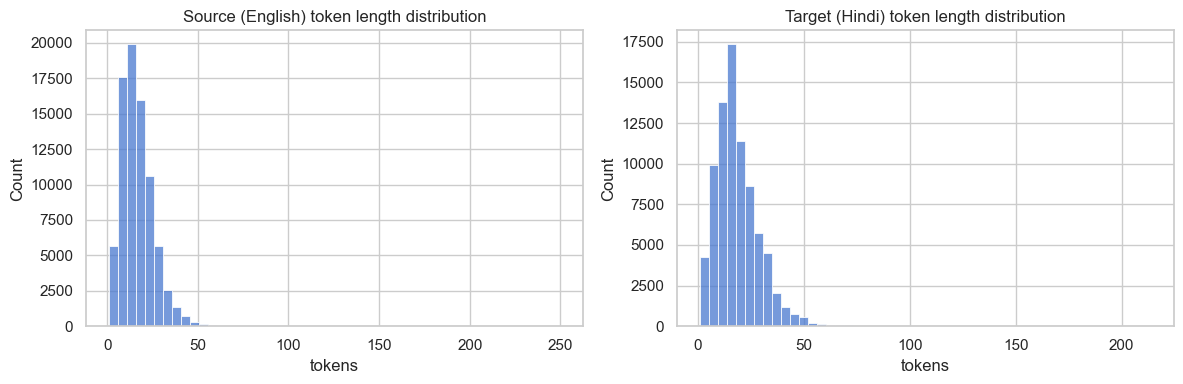

In [12]:
# Cell 8.1 - length histograms
src_lens = [len(s) for s in en_train_tokens]
tgt_lens = [len(t) for t in hi_train_tokens]

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(src_lens, bins=50, kde=False)
plt.title('Source (English) token length distribution')
plt.xlabel("tokens")

plt.subplot(1,2,2)
sns.histplot(tgt_lens, bins=50, kde=False)
plt.title('Target (Hindi) token length distribution')
plt.xlabel("tokens")

plt.tight_layout()
plt.savefig("length_histograms.png", dpi=150)
plt.show()


### 8.2 Source vs Target length scatter and ratio

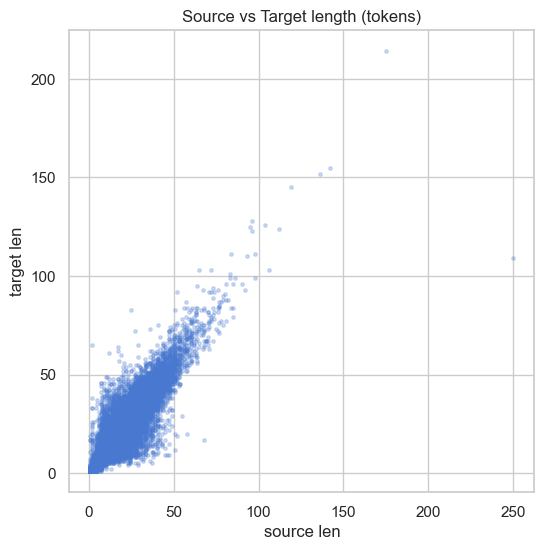

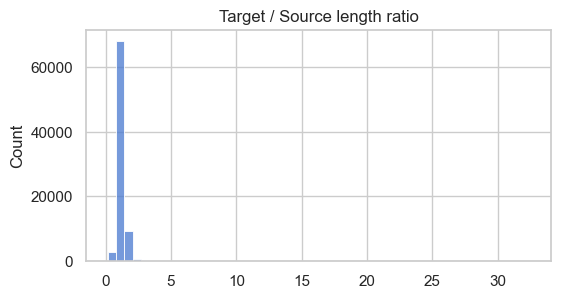

In [13]:
# Cell 8.2 - length scatter & ratio
plt.figure(figsize=(6,6))
plt.scatter(src_lens, tgt_lens, alpha=0.25, s=6)
plt.xlabel("source len")
plt.ylabel("target len")
plt.title("Source vs Target length (tokens)")
plt.savefig("len_scatter.png", dpi=150)
plt.show()

# ratio distribution
ratios = np.array(tgt_lens) / (np.array(src_lens) + 1e-8)
plt.figure(figsize=(6,3))
sns.histplot(ratios, bins=50)
plt.title("Target / Source length ratio")
plt.savefig("len_ratio_hist.png", dpi=150)
plt.show()



### 8.3 Top-k frequent tokens (bar plot)


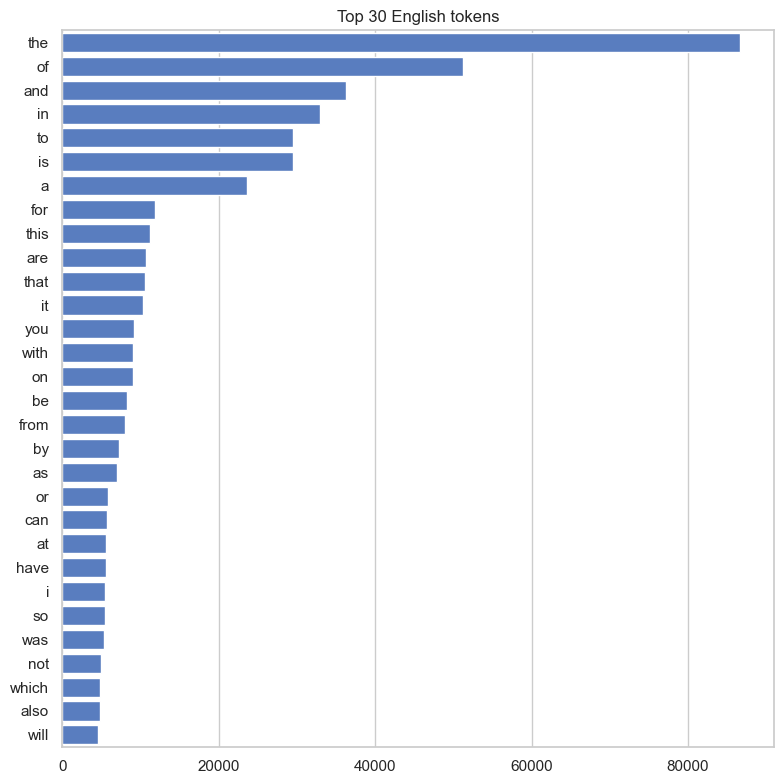

C:\Users\gunav\AppData\Local\Temp\ipykernel_14296\1258956206.py:8: UserWarning: Glyph 2404 (\N{DEVANAGARI DANDA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\gunav\AppData\Local\Temp\ipykernel_14296\1258956206.py:8: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
C:\Users\gunav\AppData\Local\Temp\ipykernel_14296\1258956206.py:8: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\gunav\AppData\Local\Temp\ipykernel_14296\1258956206.py:8: UserWarning: Glyph 2375 (\N{DEVANAGARI VOWEL SIGN E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\gunav\AppData\Local\Temp\ipykernel_14296\1258956206.py:8: UserWarning: Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\gunav\AppData\Local\Temp\ipykernel_14296\1258956206.py:8: UserWarning: Glyph 2376 (\N{DEVANAGARI VOWEL SIGN AI}) missing from font(s) Arial.
  plt.tight_layout()
C:

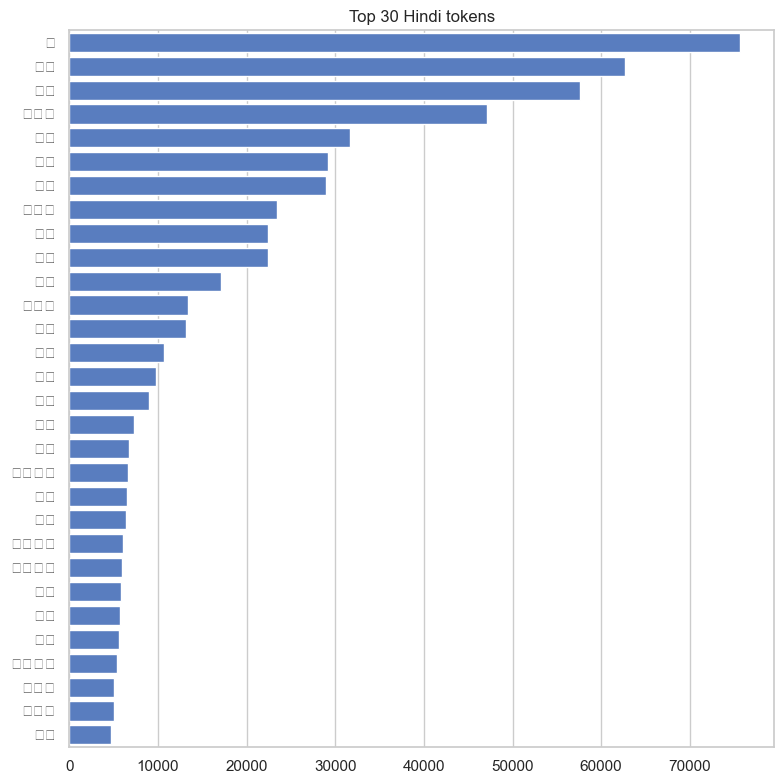

In [14]:
# Cell 8.3 - top words
def plot_top_k(counter, k=30, title="Top tokens", save_name="top_tokens.png"):
    most = counter.most_common(k)
    words, freqs = zip(*most)
    plt.figure(figsize=(8,8))
    sns.barplot(x=list(freqs), y=list(words))
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_name, dpi=150)
    plt.show()

plot_top_k(en_counter, 30, "Top 30 English tokens", "en_top30.png")
plot_top_k(hi_counter, 30, "Top 30 Hindi tokens", "hi_top30.png")


### 8.4 Rare words (counts & proportion)


In [15]:
# Cell 8.4 - rare word counts
def rare_word_stats(counter, thresholds=[1,2,5,10]):
    freqs = np.array(list(counter.values()))
    total_types = len(freqs)
    stats = {}
    for t in thresholds:
        stats[t] = int((freqs <= t).sum())
    return total_types, stats

en_types, en_rare = rare_word_stats(en_counter)
hi_types, hi_rare = rare_word_stats(hi_counter)
print("English types:", en_types, "rare:", en_rare)
print("Hindi types:", hi_types, "rare:", hi_rare)



English types: 57198 rare: {1: 28027, 2: 35977, 5: 43886, 10: 48436}
Hindi types: 69482 rare: {1: 37715, 2: 46912, 5: 55950, 10: 60680}


### 8.5 Vocab growth curve (type-token)

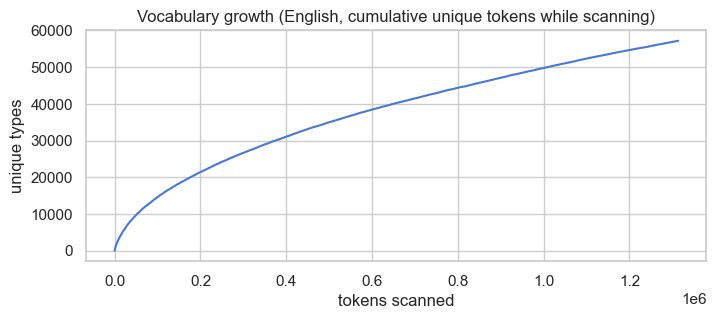

In [16]:
# Cell 8.5 - vocab growth
def vocab_growth_curve(token_lists):
    seen = set()
    growth = []
    for sent in token_lists:
        for w in sent:
            seen.add(w)
            growth.append(len(seen))
    return growth

growth = vocab_growth_curve(en_train_tokens)
plt.figure(figsize=(8,3))
plt.plot(growth)
plt.title("Vocabulary growth (English, cumulative unique tokens while scanning)")
plt.xlabel("tokens scanned")
plt.ylabel("unique types")
plt.savefig("vocab_growth_en.png", dpi=150)
plt.show()


### 8.6 Zipf plot (rank vs frequency log-log)


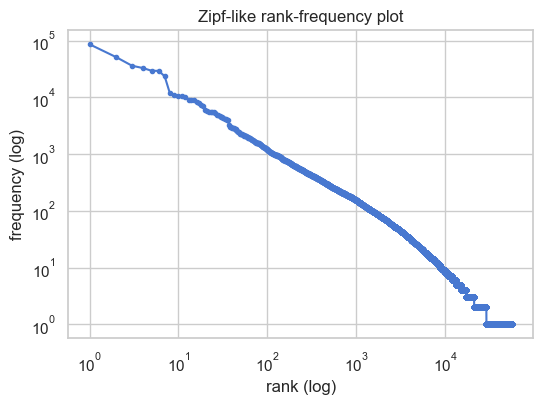

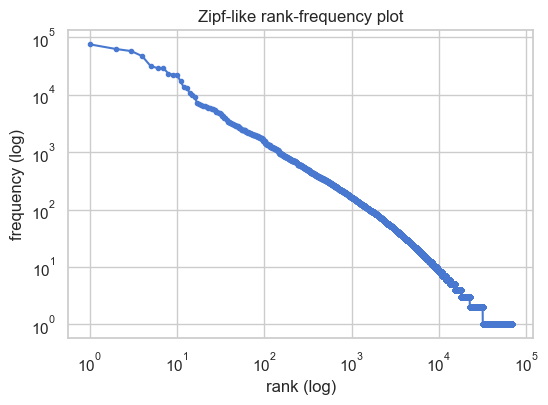

In [17]:
# Cell 8.6 - Zipf plot
def zipf_plot(counter, save_name="zipf.png"):
    freqs_sorted = np.array(sorted(counter.values(), reverse=True))
    ranks = np.arange(1, len(freqs_sorted) + 1)
    plt.figure(figsize=(6,4))
    plt.loglog(ranks, freqs_sorted, marker='.')
    plt.title("Zipf-like rank-frequency plot")
    plt.xlabel("rank (log)")
    plt.ylabel("frequency (log)")
    plt.savefig(save_name, dpi=150)
    plt.show()

zipf_plot(en_counter, "zipf_en.png")
zipf_plot(hi_counter, "zipf_hi.png")



### 8.7 seq_length choice check (your `seq_length = 20`)

Compute proportion of sentences that would be truncated given `seq_length`.

If the proportion is > ~0.05 (5%), consider increasing `seq_length` or using subword tokenization (next section).


In [18]:
# Cell 8.7 - seq_len truncation check
SEQ_LEN = 20  # your current choice (counts tokens excluding SOS/EOS)
src_long_prop = sum(1 for l in src_lens if (l + 2) > SEQ_LEN) / len(src_lens)  # +2 for SOS/EOS
tgt_long_prop = sum(1 for l in tgt_lens if (l + 2) > SEQ_LEN) / len(tgt_lens)
print(f"Proportion of source sentences that will be truncated at seq_len={SEQ_LEN}: {src_long_prop:.3f}")
print(f"Proportion of target sentences that will be truncated at seq_len={SEQ_LEN}: {tgt_long_prop:.3f}")


Proportion of source sentences that will be truncated at seq_len=20: 0.339
Proportion of target sentences that will be truncated at seq_len=20: 0.439


## 9. Optional: Train SentencePiece subword tokenizers (recommended if many OOVs)

If you saw many rare words / long tails, train SentencePiece on **only** your provided training texts (complying with competition rules).

```python
# Cell 9 - prepare raw text files for sentencepiece training
# Save raw (preprocessed) train corpora to disk, one sentence per line
with open("sp_en_train.txt", "w", encoding="utf-8") as f:
    for s in src_train:
        f.write(preprocess_text(s, lower=True, remove_punct=False) + "\n")

with open("sp_hi_train.txt", "w", encoding="utf-8") as f:
    for t in tgt_train:
        f.write(preprocess_text(t, lower=False, remove_punct=False, remove_latin=True) + "\n")

# Train two separate models (src + tgt)
VOCAB_SIZE = 8000  # tune: 4k-32k depending on data size
spm.SentencePieceTrainer.Train(f"--input=sp_en_train.txt --model_prefix=sp_en --vocab_size={VOCAB_SIZE} --model_type=bpe --character_coverage=1.0")
spm.SentencePieceTrainer.Train(f"--input=sp_hi_train.txt --model_prefix=sp_hi --vocab_size={VOCAB_SIZE} --model_type=bpe --character_coverage=1.0")

# Load models
sp_en = spm.SentencePieceProcessor()
sp_en.Load("sp_en.model")
sp_hi = spm.SentencePieceProcessor()
sp_hi.Load("sp_hi.model")

# Example encoding
print("SP example:", sp_en.encode_as_pieces("This is a test sentence."))
```

If you use subword models, encode via `sp_en.encode_as_ids()` and build vocab using the SP vocab (no extra UNK needed because SP has its own `<unk>` token).

---


## 10. Save processed artifacts

Save token lists, encoded pairs and vocabs so Week-1 trains can load them directly.

---


In [11]:
# Cell 10 - save artifacts
os.makedirs("processed", exist_ok=True)
with open("processed/vocabs_hi.pkl", "wb") as f:
    pickle.dump({
        "en_index2word_hi": en_index2word,
        "en_word2index_hi": en_word2index,
        "hi_index2word": hi_index2word,
        "hi_word2index": hi_word2index
    }, f)

# Save tokenized lists for quick reload
with open("processed/tokenized_train_hi.pkl", "wb") as f:
    pickle.dump({
        "en_train_tokens_hi": en_train_tokens,
        "hi_train_tokens": hi_train_tokens,
        "id_train": id_train
    }, f)

# English-Hindi validation
with open("processed/tokenized_val_hi.pkl", "wb") as f:
    pickle.dump({
        "en_val_tokens_hi": en_val_tokens,
        "hi_val_tokens": hi_val_tokens,
        "id_val": id_val
    }, f)

print("Saved processed artifacts in ./processed/")


Saved processed artifacts in ./processed/


## 11. Quick sanity checks & tiny overfit dataset (for debugging model code next week)

Create a tiny subset to use in Week-1 for sanity overfitting.

---

In [ ]:
# Cell 11 - tiny overfit dataset
SMALL_N = min(100, len(encoded_pairs))
small_pairs = encoded_pairs[:SMALL_N]
small_loader = DataLoader(small_pairs, batch_size=16, shuffle=True, collate_fn=collate_fn)
print("Small loader batches:", len(small_loader))
# Save small set
with open("processed/small_pairs.pkl", "wb") as f:
    pickle.dump(small_pairs, f)



## 12. Final checklist for Week-0 (what you should have)

* [x] Cleaned & tokenized train & val data (word-level).
* [x] Vocab files with `<PAD>,<SOS>,<EOS>,<UNK>` (and word2index mappings).
* [x] `DataLoader` with dynamic padding (collate_fn).
* [x] EDA figures saved: `length_histograms.png`, `len_scatter.png`, `en_top30.png`, `hi_top30.png`, zipf plots, vocab growth.
* [x] Proportion-of-truncation report for `seq_len=20` (decide to keep or increase).
* [x] Optional: SentencePiece models `sp_en.model`, `sp_hi.model` (if you trained).
* [x] Saved processed artifacts in `./processed/` (tokenized lists, vocabs, small_pairs).

---

# Quick interpretation guidance (how to read EDA & act)

* If **>5–10%** of sentences will be truncated at `seq_length=20`, **increase seq_length** or use **subword** tokenization. For NMT, subwords are usually better than word-level for Indic languages / rich morphology.
* If you see **many rare words** (e.g., >30% of types occur once), subword tokenization will likely help.
* If source and target lengths are **very different** (ratio far from 1), tune decoder max length (and use length penalty at beam search).
* If the corpus is small, a smaller transformer or RNN with moderate hidden size works better than a huge model that overfits.

---

# Bengali translation

In [16]:
with open("../dataset/train_data1.json", 'r', encoding="utf-8") as file:
    data = json.load(file)

for language_pair, language_data in data.items():
    if(language_pair == "English-Bengali"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]
              print(source)
              target = entry_data["target"]
              print(target)
              break

Language Pair: English-Bengali
  Data Type: Train
Do not forget to visit the point where the Narmada flowing through the marble rocks interchanges its calmness and serenity into insouciance.
এই জায়গাগুলো দেখতে ভুলো না যেখানে নর্মদা নদী মার্বেল পাথরের পাহাড়ের মধ্য দিয়ে প্রবাহিত হচ্ছে এবং নিজের শান্তি ও সৌন্দর্যকে অনাসক্তিতে পরিণত করছে।


In [19]:
# load data

src_train, tgt_train_be, src_val, tgt_val_be, id_train_be, id_val_be = \
    load_json([train_json, val_json], lp="English-Bengali")

print("Train pairs:", len(src_train))
print("Val sources:", len(src_val), "Val targets (available):", len(tgt_val_be))


68849
68849
9836
0
Train pairs: 68849
Val sources: 9836 Val targets (available): 0


In [20]:
print(tgt_train_be[0])

এই জায়গাগুলো দেখতে ভুলো না যেখানে নর্মদা নদী মার্বেল পাথরের পাহাড়ের মধ্য দিয়ে প্রবাহিত হচ্ছে এবং নিজের শান্তি ও সৌন্দর্যকে অনাসক্তিতে পরিণত করছে।


In [21]:
# Initialize normalizer for Bengali
normalizer_be = factory.get_normalizer("bn")  # "bn" = Bengali

def normalize_text_bengali(text):
    if text is None:
        return ""
    text = normalizer_be.normalize(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_text_bengali(text, lower=True, remove_punct=True, remove_latin=False):
    text = normalize_text_bengali(text)
    if lower:
        text = text.lower()
    if remove_punct:
        text = remove_punct_and_digits_keep_indic(text)
    if remove_latin:
        text = remove_isolated_latin_tokens(text)
    text = text.strip()
    tokens = indic_tokenize.trivial_tokenize(text, "bn")
    return ' '.join(tokens)

# Clean English source (train + val)
src_train_clean = [preprocess_english(s) for s in tqdm(src_train, desc="Cleaning English Train")]
src_val_clean   = [preprocess_english(s) for s in tqdm(src_val, desc="Cleaning English Val")]

# Clean Bengali target (train + val) using Indic pipeline
tgt_train_clean_be = [preprocess_text_bengali(s, remove_latin=True) for s in tqdm(tgt_train_be, desc="Cleaning Bengali Train")]
tgt_val_clean_be   = [preprocess_text_bengali(s, remove_latin=True) for s in tqdm(tgt_val_be, desc="Cleaning Bengali Val")]
print(f"\n✅ Train: {len(src_train)} English | {len(tgt_train_clean_be)} Bengali")
print(f"✅ Val:   {len(src_val)} English | {len(tgt_val_clean_be)} Bengali")

Cleaning English Train:   0%|          | 0/68849 [00:00<?, ?it/s]

Cleaning Bengali Train: 100%|██████████| 68849/68849 [00:04<00:00, 13985.43it/s]
Cleaning Bengali Val: 0it [00:00, ?it/s]


✅ Train: 68849 English | 68849 Bengali
✅ Val:   9836 English | 0 Bengali


In [22]:
# Tokenization for Bengali
def tokenize_list_bengali(sentences, lower=True, remove_punct=True, remove_latin=False):
    tokens = []
    for s in sentences:
        s_clean = preprocess_text_bengali(s, lower=lower, remove_punct=remove_punct, remove_latin=remove_latin)
        if s_clean == "":
            tokens.append([])   # keep empty to inspect later
        else:
            toks = word_tokenize(s_clean)
            tokens.append(toks)
    return tokens

# Apply:
en_train_tokens = tokenize_list(src_train_clean, lower=True, remove_punct=True, remove_latin=False)
en_val_tokens   = tokenize_list(src_val_clean, lower=True, remove_punct=True, remove_latin=False)

# For Bengali target, optionally remove Latin:
be_train_tokens = tokenize_list(tgt_train_clean_be, lower=False, remove_punct=True, remove_latin=True)  # case kept for Indic
be_val_tokens   = tokenize_list(tgt_val_clean_be, lower=False, remove_punct=True, remove_latin=True)

# Quick checks
print("Example source raw:", src_train[0][:200])
print("Example source tokenized:", en_train_tokens[0][:20])
print("Example target raw:", tgt_train_be[0][:200] if tgt_train else "no target")
print("Example target tokenized:", be_train_tokens[0][:20] if be_train_tokens else "no tokens")

# Cell 4 - filter out bad pairs
# --- Apply for English-Bengali ---
en_train_tokens, be_train_tokens, id_train_be = filter_train_data(en_train_tokens, be_train_tokens, id_train_be)
en_val_tokens, be_val_tokens, id_val_be = preserve_validation(en_val_tokens, be_val_tokens, id_val_be)



Example source raw: Do not forget to visit the point where the Narmada flowing through the marble rocks interchanges its calmness and serenity into insouciance.
Example source tokenized: ['do', 'not', 'forget', 'to', 'visit', 'the', 'point', 'where', 'the', 'narmada', 'flowing', 'through', 'the', 'marble', 'rocks', 'interchanges', 'its', 'calmness', 'and', 'serenity']
Example target raw: এই জায়গাগুলো দেখতে ভুলো না যেখানে নর্মদা নদী মার্বেল পাথরের পাহাড়ের মধ্য দিয়ে প্রবাহিত হচ্ছে এবং নিজের শান্তি ও সৌন্দর্যকে অনাসক্তিতে পরিণত করছে।
Example target tokenized: ['এই', 'জায়গাগুলো', 'দেখতে', 'ভুলো', 'না', 'যেখানে', 'নর্মদা', 'নদী', 'মার্বেল', 'পাথরের', 'পাহাড়ের', 'মধ্য', 'দিয়ে', 'প্রবাহিত', 'হচ্ছে', 'এবং', 'নিজের', 'শান্তি', 'ও', 'সৌন্দর্যকে']
Filtered training size: 68842
Validation size (all preserved): 9836


In [23]:
# Build separate vocabs for source & target
en_index2word, en_word2index, en_counter = build_vocab(en_train_tokens, max_vocab=None, min_freq=1)
be_index2word, be_word2index, be_counter = build_vocab(be_train_tokens, max_vocab=None, min_freq=1)

print("En vocab size:", len(en_index2word))
print("Be vocab size:", len(be_index2word))

En vocab size: 53879
Be vocab size: 95378


In [24]:
# Encode Bengali tokens

encoded_pairs_be = [(encode_tokens(s, en_word2index), encode_tokens(t, be_word2index))
                 for s,t in zip(en_train_tokens, be_train_tokens)]
val_encoded_pairs_be = [(encode_tokens(s, en_word2index), encode_tokens(t, be_word2index))
                        for s, t in zip(en_val_tokens, be_val_tokens)]

train_loader_be = DataLoader(encoded_pairs_be, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader_be = DataLoader(val_encoded_pairs_be, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)


In [24]:
# Saving Bengali artifacts
with open("processed/vocabs_bn.pkl", "wb") as f:
    pickle.dump({
        "en_index2word_bn": en_index2word,
        "en_word2index_bn": en_word2index,
        "bn_index2word": be_index2word,
        "bn_word2index": be_word2index
    }, f)

with open("processed/tokenized_train_bn.pkl", "wb") as f:
    pickle.dump({
        "en_train_tokens_bn": en_train_tokens,
        "bn_train_tokens": be_train_tokens,
        "id_train": id_train_be
    }, f)

# English-Bengali validation
with open("processed/tokenized_val_bn.pkl", "wb") as f:
    pickle.dump({
        "en_val_tokens_bn": en_val_tokens,
        "bn_val_tokens": be_val_tokens,
        "id_val": id_val_be
    }, f)

